In [1]:
from figures import *

In [2]:
import pandas as pd

data_root = "/datax/scratch/ktp/"
summary_csv = data_root + "spectrum_metadata.csv"

df = pd.read_csv(summary_csv)
print(f"there are {len(df)} rows")

there are 9198 rows


In [4]:
#lets find the top two stars w/ most data

# Find most common pairs
pair_counts = df.groupby(['location_ra', 'location_dec']).size().reset_index(name='count')
top_2 = pair_counts.nlargest(2, 'count')

print(top_2)
# print(len(pair_counts[pair_counts['count'] < 10]))

     location_ra  location_dec  count
14     111.85208       5.22579    756
179    269.45208       4.69336    523


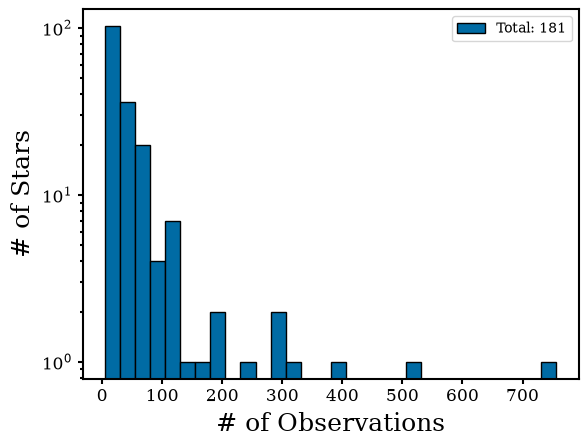

In [5]:
# lets find the distribution of observations 
plt.hist(pair_counts['count'], bins=30, edgecolor='black', label=f"Total: {len(pair_counts)}")
plt.yscale('log')
plt.ylabel("# of Stars")
plt.xlabel("# of Observations")
plt.legend()
plt.show()

In [3]:
## from the html query, these are:
## Lutyen's Star J07274+052 (14) and Barnard's Star J17578+046 (179)

In [6]:
lutyen_path = data_root + "carmenes_data_J07274+052_car-20160108T01h39m51s-sci-gtoc-vis_A.vot"

In [7]:
from astropy.io.votable import parse
from astropy.table import Table

# to ignore "Angstroms" as an outdated label
import warnings
from astropy.units import UnitsWarning
warnings.filterwarnings("ignore", category=UnitsWarning)

vot = parse(lutyen_path)

print(n_tables)
table = vot.get_first_table().to_table()

print(table.colnames)
print(table[:5])

60
['spectral', 'flux', 'cont_flux', 'err_flux']
     spectral               flux           cont_flux     err_flux  
     Angstrom                                  ct           ct     
------------------ --------------------- ------------- ------------
10450.780574816488  0.005203660577535629  1.001359e-09 0.0050898367
 10450.83569143984 0.0009718688088469207 1.0017993e-09 0.0051361136
10450.890960835246 -0.007222277577966452 1.0022413e-09 0.0053579584
10450.946224944923 -0.007174082566052675 1.0026836e-09 0.0052561997
10451.001483756969 -0.002918460639193654 1.0031261e-09 0.0052612163


Text(0, 0.5, 'Flux')

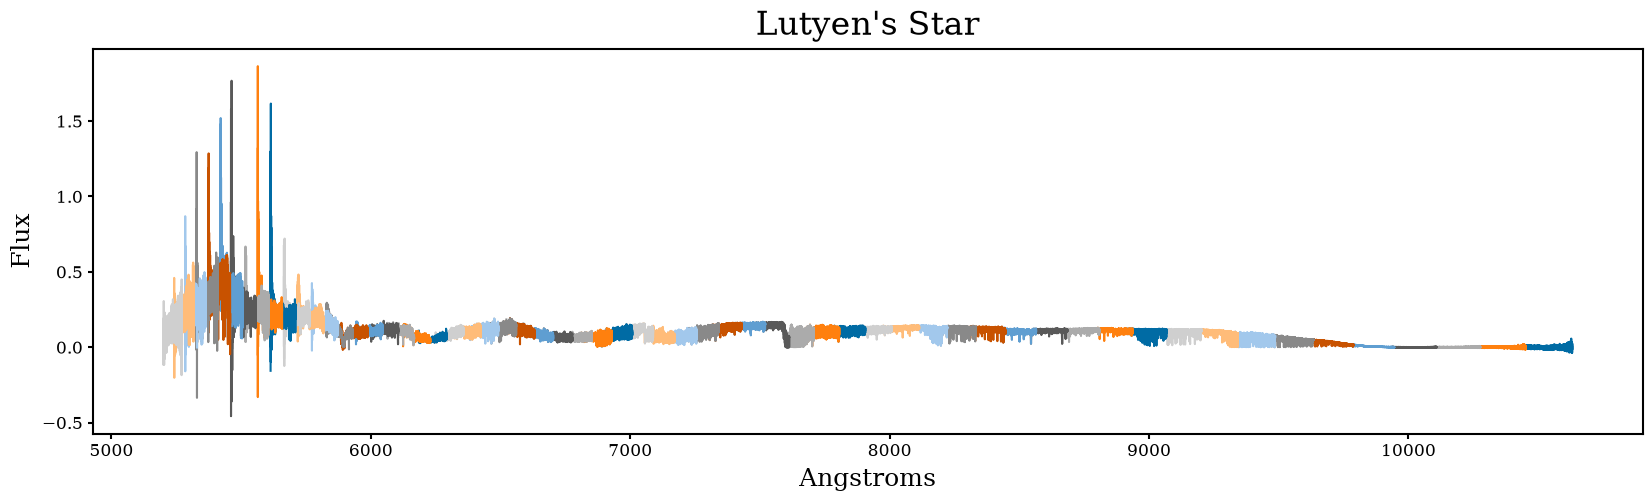

In [15]:
n_tables = 1
plt.figure(figsize=(20, 5))

for tab in vot.iter_tables():
    table = tab.to_table()
    if n_tables > 1:
        plt.plot(table[f'spectral-{n_tables:02d}'], table[f'flux-{n_tables:02d}'])
    else:
        plt.plot(table['spectral'], table['flux'])

    # plt.show()
    
    n_tables+=1
plt.title(f"Lutyen's Star")
plt.xlabel('Angstroms')
plt.ylabel('Flux')

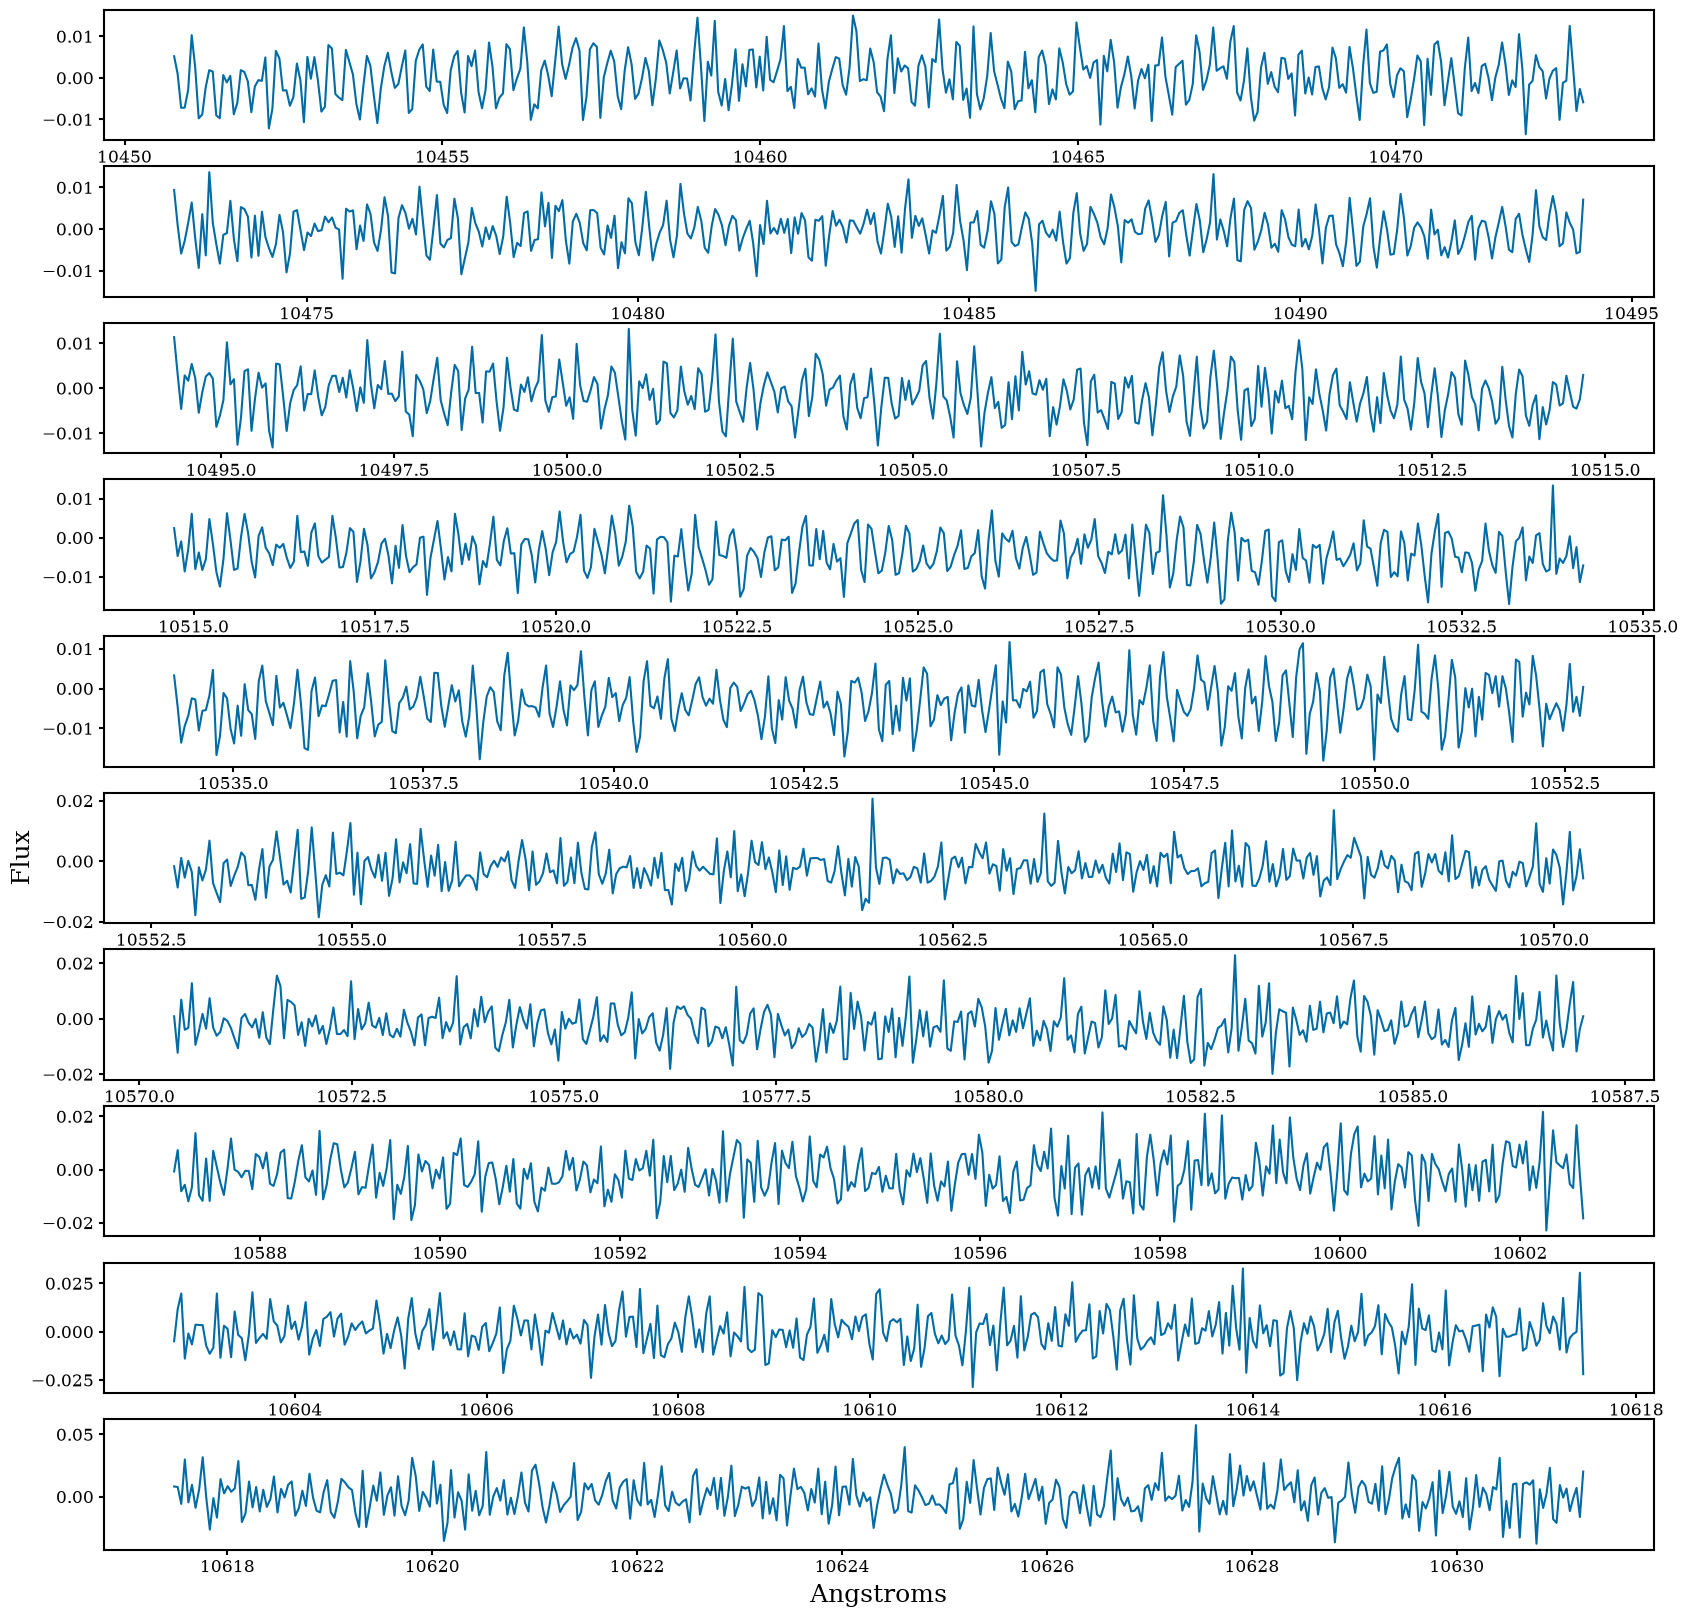

In [43]:
plot_spectra_elike(table['spectral'], 
                   table['flux'], 
                   10, 
                   xlabel="Angstroms",
                   ylabel="Flux")